In [1]:
!pip install feature-engine
!pip install catboost

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 378.6/378.6 KB 3.3 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 10.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.9/232.9 KB 3.4 MB/s eta 0:00:00a 0:00:01
Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 5.9 MB/s eta 0:00:00:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 9.6 MB/s eta 0:00:00:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.1/47.1 KB 640.7 kB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 358.0/358.0 KB 4.0 MB/s eta 0:00:00a 0:00:01


In [6]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from feature_engine.selection import SmartCorrelatedSelection
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn import set_config
from sklearn.base import clone
from sklearn.base import BaseEstimator, TransformerMixin

from itertools import combinations
from scipy.stats import pointbiserialr

pd.set_option('display.max_columns', None)
set_config(transform_output='pandas')

In [20]:
ROOT = "/content/drive/MyDrive/ml-project"
FILE = "smart-contract-dataset.csv"
SEED = 78

In [21]:
data = pd.read_csv(os.path.join(FILE))

In [22]:
data = data.rename(
    columns=lambda col: (
        col
        .replace('<', 'lt')
        .replace('>', 'gt')
        .replace('__', '_double_underscore')
        .replace(':', '_colon')
    )
)

In [23]:
X = data.iloc[:, 3:].select_dtypes(include="number")
y = data.label

In [24]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, random_state=SEED
)

print(X_train.shape, X_val.shape, X_test.shape)

(23468, 263) (5868, 263) (7335, 263)


In [25]:
class TreeFeatureSelector(BaseEstimator, TransformerMixin):
    def __init__(self, k=15, random_state=42):
        self.k = k
        self.random_state = random_state

    def fit(self, X, y):
        self.feature_names_in_ = X.columns
        self.tree_ = DecisionTreeClassifier(random_state=self.random_state)
        self.tree_.fit(X, y)
        importances = self.tree_.feature_importances_
        indices = np.argsort(importances)[::-1][:self.k]
        self.selected_features_ = self.feature_names_in_[indices]

        return self

    def transform(self, X):

        return X[self.selected_features_]


class SelectiveInteraction(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.05):
        self.threshold = threshold
        self.interactions_ = []

    def fit(self, X, y):
        X = pd.DataFrame(X).copy()
        y = pd.Series(y).copy()

        if not set(np.unique(y)).issubset({0, 1}):
            raise ValueError("Target `y` must be binary (0/1) for point-biserial correlation.")

        self.feature_corr_ = {
            col: pointbiserialr(X[col], y)[0]
            for col in X.columns
        }
        self.interactions_ = [
            (f1, f2)
            for f1, f2 in combinations(X.columns, 2)
            if abs(self.feature_corr_[f1]) >= self.threshold
            and abs(self.feature_corr_[f2]) >= self.threshold
            and np.sign(self.feature_corr_[f1]) != np.sign(self.feature_corr_[f2])
        ]

        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        new_features = {
            f"{f1}_x_{f2}": X[f1] * X[f2]
            for f1, f2 in self.interactions_
        }
        X_new = pd.concat([X, pd.DataFrame(new_features, index=X.index)], axis=1)

        return X_new

### Naive Bayes

In [26]:
feature_selection_steps = Pipeline(
    [
        (
            "LowVarianceFeatureSelector", VarianceThreshold(
                threshold=1e-4
            )
        ),
        (
            "SmartCorrelatedSelection", SmartCorrelatedSelection(
                threshold=.9,
                missing_values='ignore',
                selection_method='variance'
            )
        ),
    ]
)


preprocessing_pipeline = Pipeline(
    [
        (
            "FeatureSelection", feature_selection_steps
        ),
        # (
        #     "SelectiveInteraction", SelectiveInteraction(threshold=0.01)
        # ),
        # (
        #     "Scaler", StandardScaler()
        # )
    ]
)


naive_bayes_pipeline = Pipeline(
    [
        (
            "Preprocessing", preprocessing_pipeline
        ),
        (
            "Classifier", GaussianNB()
        )
    ]
)

In [27]:
# X_train_ = preprocessing_pipeline.fit_transform(X_train, y_train)
# X_val_ = preprocessing_pipeline.transform(X_val)

In [28]:
naive_bayes_pipeline.fit(X_train, y_train)
y_pred = naive_bayes_pipeline.predict(X_val)

In [29]:
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.76      0.87      0.81      4238
           1       0.45      0.27      0.34      1630

    accuracy                           0.71      5868
   macro avg       0.60      0.57      0.57      5868
weighted avg       0.67      0.71      0.68      5868



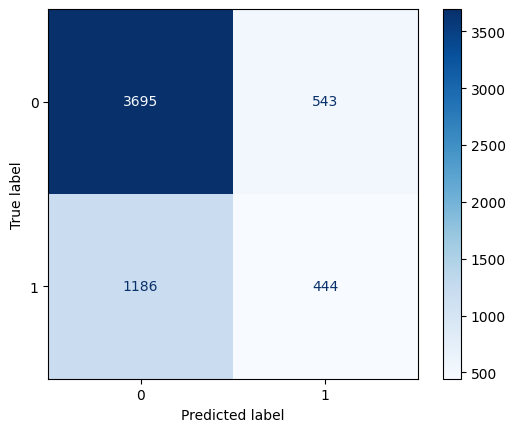

In [30]:
ConfusionMatrixDisplay.from_predictions(y_val, y_pred, cmap='Blues');

### Decision Trees

In [31]:
decicion_tree_hyperparameters = {
    "max_depth": 15,
    "class_weight": "balanced",
    "random_state": SEED
}



feature_selection_steps = Pipeline(
    [
        (
            "LowVarianceFeatureSelector", VarianceThreshold(
                threshold=1e-4
            )
        ),
        (
            "SmartCorrelatedSelection", SmartCorrelatedSelection(
                threshold=.9,
                missing_values='ignore',
                selection_method='variance'
            )
        ),
        (
            "FeatureSelection", TreeFeatureSelector(k=50)
        )
    ]
)


preprocessing_pipeline = Pipeline(
    [
        (
            "FeatureSelection", feature_selection_steps
        ),
        (
            "SelectiveInteraction", SelectiveInteraction(threshold=0.01)
        )
    ]
)


decision_tree_pipeline = Pipeline(
    [
        (
            "Preprocessing", preprocessing_pipeline
        ),
        (
            "Cassifier", DecisionTreeClassifier(
                **decicion_tree_hyperparameters
            )
        )
    ]
)

In [32]:
# X_train_ = preprocessing_pipeline.fit_transform(X_train, y_train)
# X_val_ = preprocessing_pipeline.transform(X_val)

In [33]:
decision_tree_pipeline.fit(X_train, y_train)
y_pred = decision_tree_pipeline.predict(X_val)

In [34]:
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.77      0.80      4238
           1       0.51      0.61      0.55      1630

    accuracy                           0.73      5868
   macro avg       0.67      0.69      0.68      5868
weighted avg       0.74      0.73      0.73      5868



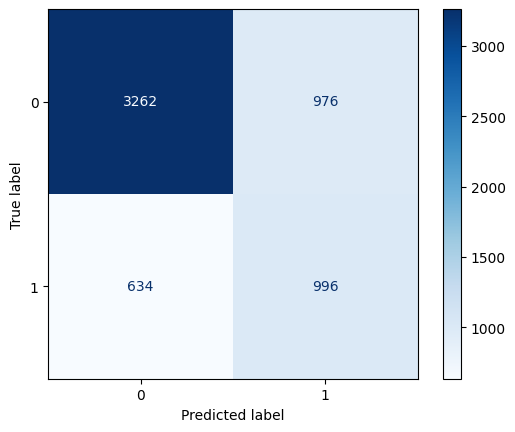

In [35]:
ConfusionMatrixDisplay.from_predictions(y_val, y_pred, cmap='Blues');

### Logistic Regression

In [36]:
logistic_regression_hyperparameters = {
    'penalty': 'l2',
    'C': 1.0,
    'solver': 'lbfgs',
    'max_iter': 1000,
    'class_weight': 'balanced',
    'random_state': SEED
}

feature_selection_steps = Pipeline(
    [
        (
            "LowVarianceFeatureSelector", VarianceThreshold(
                threshold=1e-4
            )
        ),
        (
            "SmartCorrelatedSelection", SmartCorrelatedSelection(
                threshold=.8,
                missing_values='ignore',
                selection_method='variance'
            )
        ),
        # (
        #     "FeatureSelection", TreeFeatureSelector(k=50)
        # )
    ]
)


preprocessing_pipeline = Pipeline(
    [
        (
            "FeatureSelection", feature_selection_steps
        ),
        (
            "SelectiveInteraction", SelectiveInteraction(threshold=0.01)
        ),
        (
            "Scaler", StandardScaler()
        )
    ]
)


logistic_regression_pipeline = Pipeline(
    [
        (
            "Preprocessing", preprocessing_pipeline
        ),
        (
            "Classifier", LogisticRegression(
                **logistic_regression_hyperparameters
            )
        )
    ]
)

In [37]:
# X_train_ = preprocessing_pipeline.fit_transform(X_train, y_train)
# X_val_ = preprocessing_pipeline.transform(X_val)

In [38]:
logistic_regression_pipeline.fit(X_train, y_train)
y_pred = logistic_regression_pipeline.predict(X_val)

In [39]:
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.78      0.79      4238
           1       0.47      0.52      0.50      1630

    accuracy                           0.71      5868
   macro avg       0.64      0.65      0.64      5868
weighted avg       0.72      0.71      0.71      5868



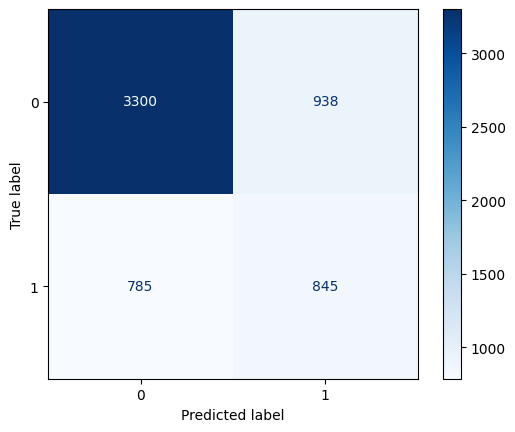

In [40]:
ConfusionMatrixDisplay.from_predictions(y_val, y_pred, cmap='Blues');

### Linear SVC

In [41]:
linear_svc_hyperparameters = {
    'C': 1.0,
    'tol': 1e-4,
    'max_iter': 1000,
    'class_weight': 'balanced',
    'random_state': SEED
}


feature_selection_steps = Pipeline(
    [
        (
            "LowVarianceFeatureSelector", VarianceThreshold(
                threshold=1e-4
            )
        ),
        (
            "SmartCorrelatedSelection", SmartCorrelatedSelection(
                threshold=.8,
                missing_values='ignore',
                selection_method='variance'
            )
        ),
        # (
        #     "FeatureSelection", TreeFeatureSelector(k=50)
        # )
    ]
)


preprocessing_pipeline = Pipeline(
    [
        (
            "FeatureSelection", feature_selection_steps
        ),
        (
            "SelectiveInteraction", SelectiveInteraction(threshold=0.01)
        ),
        (
            "Scaler", StandardScaler()
        )
    ]
)



linear_svc_pipeline = Pipeline(
    [
        (
            "Preprocessing", preprocessing_pipeline
        ),
        (
            "Classifier", LinearSVC(
                **linear_svc_hyperparameters
            )
        )
    ]
)

In [42]:
linear_svc_pipeline.fit(X_train, y_train)
y_pred = linear_svc_pipeline.predict(X_val)

In [43]:
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.77      0.79      4238
           1       0.47      0.52      0.49      1630

    accuracy                           0.70      5868
   macro avg       0.64      0.64      0.64      5868
weighted avg       0.71      0.70      0.71      5868



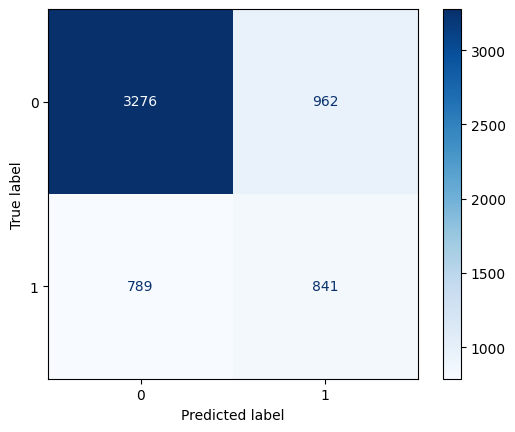

In [44]:
ConfusionMatrixDisplay.from_predictions(y_val, y_pred, cmap='Blues');

### SVM

In [45]:
svm_hyperparameters = {
    'C': 1.0,
    'kernel': 'rbf',
    'gamma': 'scale',
    'tol': 1e-3,
    'max_iter': 15000,
    'class_weight': 'balanced',
    'random_state': SEED
}


feature_selection_steps = Pipeline(
    [
        (
            "LowVarianceFeatureSelector", VarianceThreshold(
                threshold=1e-4
            )
        ),
        (
            "SmartCorrelatedSelection", SmartCorrelatedSelection(
                threshold=.8,
                missing_values='ignore',
                selection_method='variance'
            )
        ),
        (
            "TreeFeatureSelector", TreeFeatureSelector(k=30)
        )
    ]
)


preprocessing_pipeline = Pipeline(
    [
        (
            "FeatureSelection", feature_selection_steps
        ),
        (
            "SelectiveInteraction", SelectiveInteraction(threshold=0.01)
        ),
        (
            "Scaler", StandardScaler()
        )
    ]
)


svm_pipeline = Pipeline(
    [
        (
            "Preprocessing", preprocessing_pipeline
        ),
        (
            "Classifier", SVC(
                **svm_hyperparameters
            )
        )
    ]
)

In [46]:
svm_pipeline.fit(X_train, y_train)
y_pred = svm_pipeline.predict(X_val)

/home/tiagoriosrocha/.local/lib/python3.10/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=15000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


In [47]:
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.77      0.80      4238
           1       0.50      0.61      0.55      1630

    accuracy                           0.72      5868
   macro avg       0.67      0.69      0.67      5868
weighted avg       0.74      0.72      0.73      5868



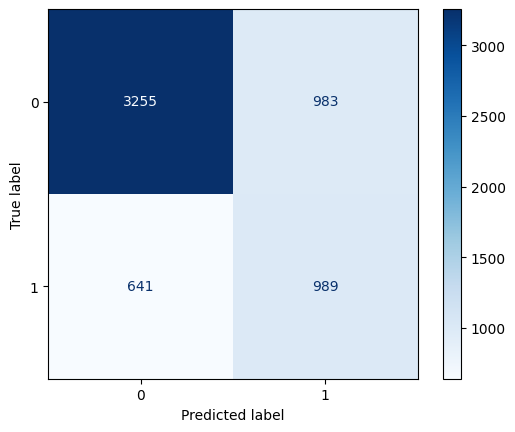

In [48]:
ConfusionMatrixDisplay.from_predictions(y_val, y_pred, cmap='Blues');

### Random Forest

In [50]:
random_forest_hyperparameters = {
    'n_estimators': 100,
    'criterion': 'gini',
    'max_depth': 10,
    'min_samples_split': 2,
    'min_samples_leaf': 1,
    'max_features': 'sqrt',
    'bootstrap': True,
    'class_weight': 'balanced',
    'random_state': SEED
}


feature_selection_steps = Pipeline(
    [
        (
            "LowVarianceFeatureSelector", VarianceThreshold(
                threshold=1e-4
            )
        ),
        (
            "SmartCorrelatedSelection", SmartCorrelatedSelection(
                threshold=.8,
                missing_values='ignore',
                selection_method='variance'
            )
        ),
        (
            "FeatureSelection", TreeFeatureSelector(k=50)
        )
    ]
)


preprocessing_pipeline = Pipeline(
    [
        (
            "FeatureSelection", feature_selection_steps
        ),
        (
            "SelectiveInteraction", SelectiveInteraction(threshold=0.01)
        ),
        (
            "Scaler", StandardScaler()
        )
    ]
)

random_forest_pipeline = Pipeline(
    [
        (
            "Preprocessing", preprocessing_pipeline
        ),
        (
            "Classifier", RandomForestClassifier(
                **random_forest_hyperparameters
            )
        )
    ]
)

In [51]:
random_forest_pipeline.fit(X_train, y_train)
y_pred = random_forest_pipeline.predict(X_val)

In [52]:
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.80      0.83      4238
           1       0.55      0.63      0.59      1630

    accuracy                           0.75      5868
   macro avg       0.70      0.72      0.71      5868
weighted avg       0.77      0.75      0.76      5868



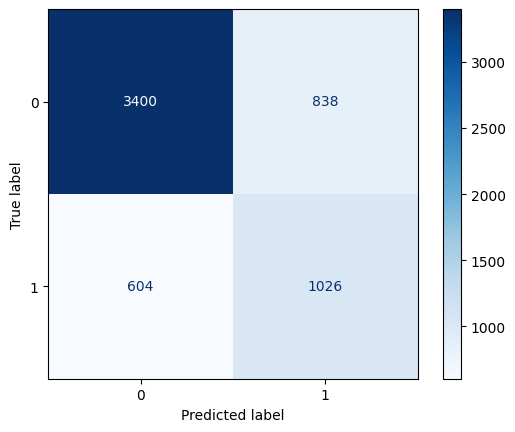

In [53]:
ConfusionMatrixDisplay.from_predictions(y_val, y_pred, cmap='Blues');

### Adaboost

In [54]:
adaboost_hyperparameters = {
    'estimator': DecisionTreeClassifier(max_depth=3, class_weight='balanced'),
    'n_estimators': 50,
    'learning_rate': 1.0,
    'random_state': SEED
}


feature_selection_steps = Pipeline(
    [
        (
            "LowVarianceFeatureSelector", VarianceThreshold(
                threshold=1e-4
            )
        ),
        (
            "SmartCorrelatedSelection", SmartCorrelatedSelection(
                threshold=.8,
                missing_values='ignore',
                selection_method='variance'
            )
        ),
        (
            "FeatureSelection", TreeFeatureSelector(k=50)
        )
    ]
)


preprocessing_pipeline = Pipeline(
    [
        (
            "FeatureSelection", feature_selection_steps
        ),
        (
            "SelectiveInteraction", SelectiveInteraction(threshold=0.01)
        ),
        # (
        #     "Scaler", StandardScaler()
        # )
    ]
)

adaboost_pipeline = Pipeline(
    [
        (
            "Preprocessing", preprocessing_pipeline
        ),
        (
            "Classifier", AdaBoostClassifier(
                **adaboost_hyperparameters
            )
        )
    ]
)

In [55]:
adaboost_pipeline.fit(X_train, y_train)
y_pred = adaboost_pipeline.predict(X_val)

In [56]:
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.81      0.81      4238
           1       0.51      0.51      0.51      1630

    accuracy                           0.73      5868
   macro avg       0.66      0.66      0.66      5868
weighted avg       0.73      0.73      0.73      5868



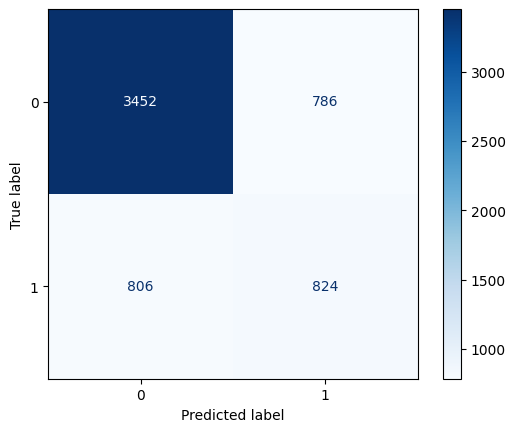

In [57]:
ConfusionMatrixDisplay.from_predictions(y_val, y_pred, cmap='Blues');

### XGBoost

In [58]:
xgboost_hyperparameters = {
    "objective": "binary:logistic",
    "eval_metric": "aucpr",
    "scale_pos_weight": 3,
    "learning_rate": 0.05,
    "max_depth":6,
    "min_child_weight": 1,
    "gamma": 0.2,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "lambda": 1.0,
    "alpha": 0.0,
    "n_estimators": 500,
    "verbosity": 1,
    "random_state": SEED
}


feature_selection_steps = Pipeline(
    [
        (
            "LowVarianceFeatureSelector", VarianceThreshold(
                threshold=1e-4
            )
        ),
        (
            "SmartCorrelatedSelection", SmartCorrelatedSelection(
                threshold=.7,
                missing_values='ignore',
                selection_method='variance'
            )
        ),
        (
            "FeatureSelection", TreeFeatureSelector(k=50)
        )
    ]
)


preprocessing_pipeline = Pipeline(
    [
        (
            "FeatureSelection", feature_selection_steps
        ),
        (
            "SelectiveInteraction", SelectiveInteraction(threshold=0.01)
        )
    ]
)


xgboost_pipeline = Pipeline(
    [
        (
            "Preprocessing", preprocessing_pipeline
        ),
        (
            "Classifier", XGBClassifier(
                **xgboost_hyperparameters
            )
        )
    ]
)

In [59]:
xgboost_pipeline.fit(X_train, y_train)
y_pred = xgboost_pipeline.predict(X_val)

In [60]:
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.78      0.82      4238
           1       0.54      0.68      0.60      1630

    accuracy                           0.75      5868
   macro avg       0.70      0.73      0.71      5868
weighted avg       0.77      0.75      0.76      5868



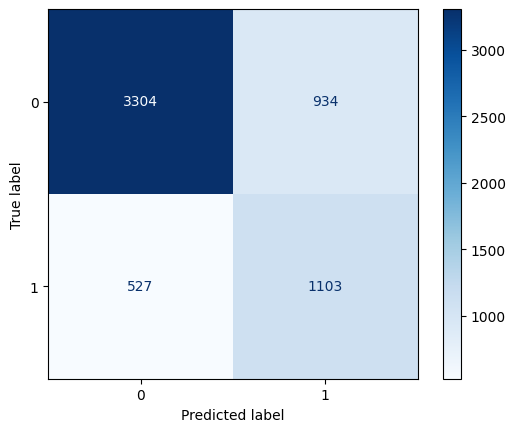

In [61]:
ConfusionMatrixDisplay.from_predictions(y_val, y_pred, cmap='Blues');

### LightGBM

In [62]:
lightgbm_hyperparameters = {
    "objective": "binary",
    "metric": "aucpr",
    "is_unbalance": True,
    "learning_rate": 0.05,
    "num_leaves": 31,
    "max_depth": -1,
    "min_child_samples": 20,
    "min_child_weight": 1e-3,
    "subsample": 0.8,
    "subsample_freq": 1,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.0,
    "reg_lambda": 1.0,
    "n_estimators": 500,
    "verbosity": -1,
    "random_state": SEED
}


feature_selection_steps = Pipeline(
    [
        (
            "LowVarianceFeatureSelector", VarianceThreshold(
                threshold=1e-4
            )
        ),
        (
            "SmartCorrelatedSelection", SmartCorrelatedSelection(
                threshold=.7,
                missing_values='ignore',
                selection_method='variance'
            )
        ),
        (
            "FeatureSelection", TreeFeatureSelector(k=50)
        )
    ]
)


preprocessing_pipeline = Pipeline(
    [
        (
            "FeatureSelection", feature_selection_steps
        ),
        (
            "SelectiveInteraction", SelectiveInteraction(threshold=0.01)
        )
    ]
)


lightgbm_pipeline = Pipeline(
    [
        (
            "Preprocessing", preprocessing_pipeline
        ),
        (
            "Classifier", LGBMClassifier(
                **lightgbm_hyperparameters
            )
        )
    ]
)

In [63]:
lightgbm_pipeline.fit(X_train, y_train)
y_pred = lightgbm_pipeline.predict(X_val)

In [64]:
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.79      0.82      4238
           1       0.55      0.69      0.61      1630

    accuracy                           0.76      5868
   macro avg       0.71      0.74      0.72      5868
weighted avg       0.78      0.76      0.76      5868



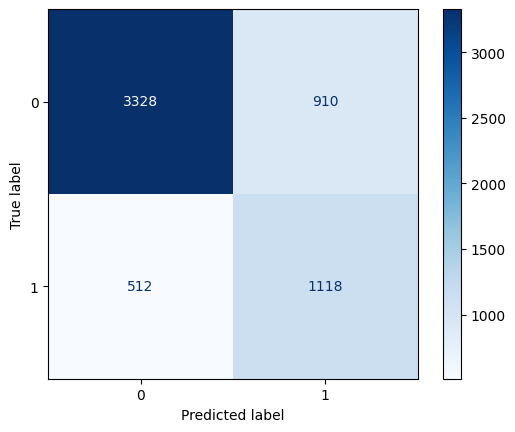

In [65]:
ConfusionMatrixDisplay.from_predictions(y_val, y_pred, cmap='Blues');

### CatBoost

In [66]:
catboost_hyperparaters = {
    "iterations": 1000,
    "learning_rate": 0.05,
    "depth": 6,
    "l2_leaf_reg": 3,
    "random_strength": 1.5,
    "bagging_temperature": 1.0,
    "border_count": 128,
    "loss_function": "Logloss",
    "eval_metric": "F1",
    "scale_pos_weight": 3,
    "verbose": 0,
    "task_type": "CPU",
    "random_seed": SEED
}


feature_selection_steps = Pipeline(
    [
        (
            "LowVarianceFeatureSelector", VarianceThreshold(
                threshold=1e-4
            )
        ),
        (
            "SmartCorrelatedSelection", SmartCorrelatedSelection(
                threshold=.7,
                missing_values='ignore',
                selection_method='variance'
            )
        ),
        (
            "FeatureSelection", TreeFeatureSelector(k=50)
        )
    ]
)


preprocessing_pipeline = Pipeline(
    [
        (
            "FeatureSelection", feature_selection_steps
        ),
        (
            "SelectiveInteraction", SelectiveInteraction(threshold=0.01)
        )
    ]
)


catboost_pipeline = Pipeline(
    [
        (
            "Preprocessing", preprocessing_pipeline
        ),
        (
            "Classifier", CatBoostClassifier(
                **catboost_hyperparaters
            )
        )
    ]
)

In [67]:
catboost_pipeline.fit(X_train, y_train)
y_pred = catboost_pipeline.predict(X_val)

In [68]:
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.76      0.81      4238
           1       0.53      0.70      0.60      1630

    accuracy                           0.74      5868
   macro avg       0.70      0.73      0.71      5868
weighted avg       0.77      0.74      0.75      5868



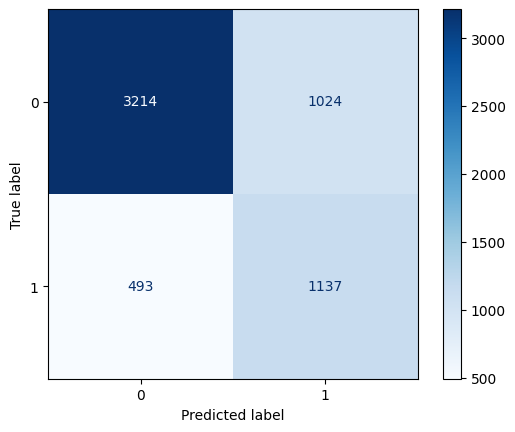

In [91]:
ConfusionMatrixDisplay.from_predictions(y_val, y_pred, cmap='Blues');